<img src="../logo_UTN.svg" align="right" width="150" /> 

# Teoría De Circuitos 2

# Trabajo de Laboratorio Nº1
#### Grupo Nº1

### Consigna

<div align="center">

|  Grupo  |     Función de aproximación     | Frecuencia de corte | Frecuencia de stop | Atenuación máxima en banda de paso | Atenuación mínima en banda de stop |
|:------:|:-------------------------------:|:-------------------:|:------------------:|:----------------------------------:|:----------------------------------:|
|   1    |           Chebyshev             |      1.5 kHz        |      4.5 kHz       |              0.5 dB                |               16 dB                |

</div>

In [1]:
from IPython.display import HTML

file = "./TPL1_handwritten.pdf"
html = f"""
<div style="text-align:center;">
    <iframe src="{file}" width="900" height="600"></iframe>
</div>
"""
HTML(html)

In [2]:
# SetUp - Import /utils module
import sys
import os

sys.path.append(os.path.abspath(".."))
import utils.plot as uplt
import utils.synth as usynth
import utils.tools as ut

# Import common packages
from IPython.display import display, Markdown
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from pytc2.sistemas_lineales import plot_plantilla, bodePlot
import pandas as pd

## Análisis de la Transferencia
Se Utilizan los valores de $Q$, $\omega_0$ y $k$ obtenidos manualmente (PDF adjunto).

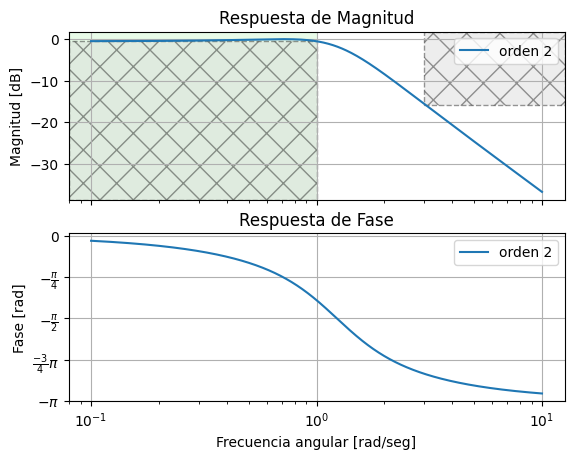

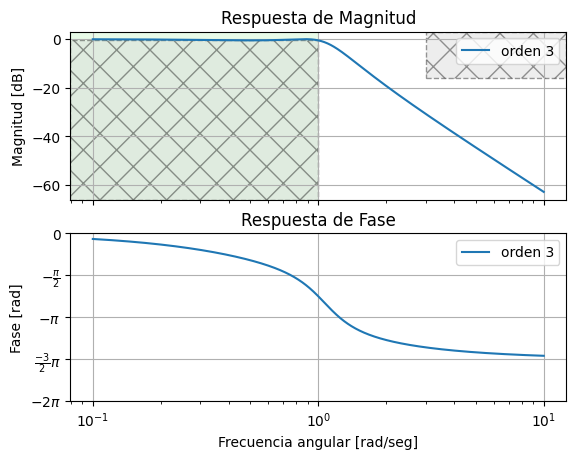

In [3]:
Q = 0.863
w0 = np.sqrt(1.5162)
k = 0.9438


num = np.array([k * w0**2])
den = np.array([1.0, w0 / Q, w0**2])

H = sig.TransferFunction(num, den)

fig_id, axes_hdl = bodePlot(
    H,
    xaxis="omega",
    filter_description="orden 2",
    fs=2 * np.pi,
)

plt.sca(axes_hdl[0])

plot_plantilla(filter_type="lowpass", fpass=1.0, ripple=0.5, fstop=3.0, attenuation=16)


c = 1.2529
a = 0.7157
b = 1.5349

num = np.array([a])
den = np.array([1.0, c, b, a])

H = sig.TransferFunction(num, den)

fig_id, axes_hdl = bodePlot(
    H,
    xaxis="omega",
    filter_description="orden 3",
    fs=2 * np.pi,
)

plt.sca(axes_hdl[0])

plot_plantilla(filter_type="lowpass", fpass=1.0, ripple=0.5, fstop=3.0, attenuation=16)

# Circuito Propuesto

Se utiliza la transferencia de un Ackerberg-Mossberg

$$
H(s) = - \frac{R_3}{R_1} \;  \cfrac{\frac{1}{{R_3}^2 \, C^2}}{s^2 + s \, \frac{1}{R_2\, C} + \frac{1}{{R_3}^2 \, C^2}}
$$

Por lo tanto se tiene la siguiente expresión simplificada:

$$
H(s) = - k \;  \cfrac{{\omega_0}^2}{s^2 + s \, \frac{\omega_0}{Q} + {\omega_0}^2}
$$

Siendo los parámetros característicos del filtro:

$$k = \frac{R_3}{R_1}$$

$$\omega_0 =  \frac{1}{R_3 \, C}$$

$$Q =  \frac{R_2}{R_3}$$

# Síntesis - Orden 2

$$\Omega_{\omega_0} = \omega_0$$

$$\Omega_{Z} = R_3 = 1$$

Quedando con la siguiente transferencia:

$$
H(s) = - \frac{1}{R_1} \;  \cfrac{1}{s^2 + s \, \frac{1}{R_2} + 1}
$$

Siendo los parámetros característicos del filtro:

$$k = \cfrac{1}{R_1}$$

$$\omega_0 =  \frac{1}{C}$$

$$Q =  R_2$$

Se requiere cumplir con los siguientes valores para cumplir con la transferencia deseada:

$$k = 0.9438$$
  
$$Q = 0.863$$

$$\omega_0 = \sqrt{1.5162}$$

$$\Omega_Z = R_3 == 1$$

$$H(s) = -1.35E^{8} \frac{1}{1s^2 + 1.34E^{4}s + 1.35E^{8}}$$

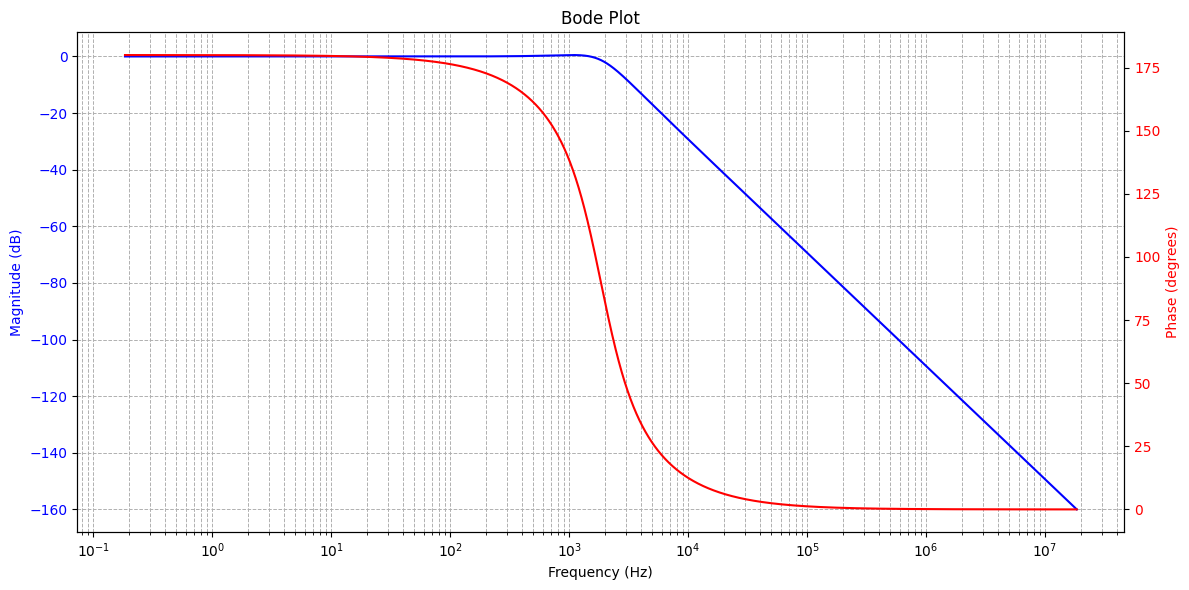


Ganancia en $\omega_{s}$ = (4500.0): -15.098[dB]

Ganancia en $\omega_{c}$ = (1500.0): -0.007[dB]


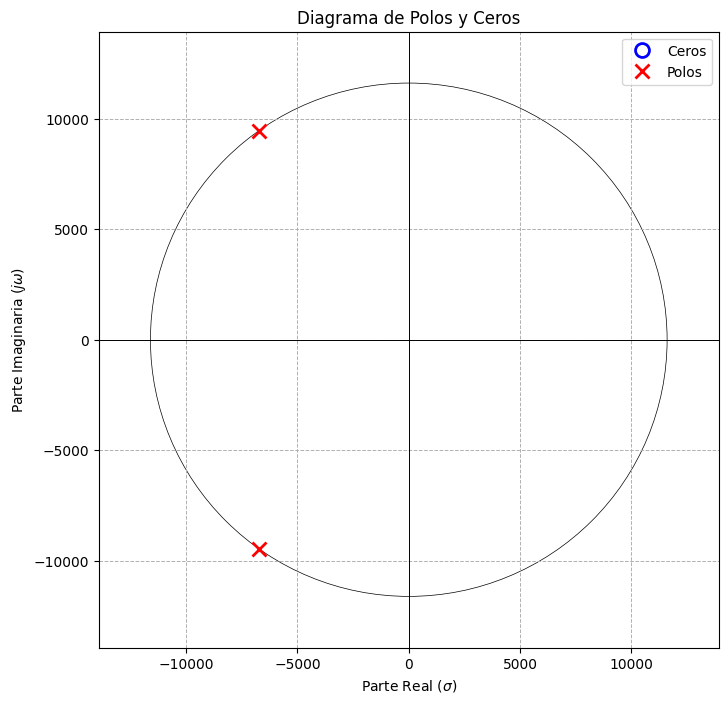


### Valor numérico normalizado:
$$C = 1.00$$
### Valor numérico de $R_3$ seteando $C = 10 nF$ y $\omega_n \omega_0 = 11605.11[rad/s]$:
$$R_3 = 8.62 k\Omega$$
### Valor numérico de $R_1 = \frac{R_3}{k}$:
$$R_1 = 9.13 k\Omega$$
### Valor numérico de $R_2 = Q \cdot R_3$:
$$R_2 = 7.44 k\Omega$$
### Verificación de resultados ($C = \frac{C_{\text{normalizado}}}{\omega_0 \; \omega_n \; \Omega_Z}$):
$$C = 10 nF$$


In [4]:
w_cheby = np.sqrt(1.5162)
fc = 1.5e3
w_c = 2 * np.pi * fc
_w0 = w_cheby * w_c

_Q = 0.863
_k = 0.9438

components = {"C": 1 / _w0, "R1": 1 / _k, "R2": _Q, "R3": 1}
T, _ = usynth.synth_ackerberg_mossberg(components=components)
(magnitude_db, frequencies, _) = uplt.plot_tf(T, {}, _w0 / (2 * np.pi))

idx = np.argmin(np.abs(frequencies - (3 * w_c) / (2 * np.pi)))
magnitude_at_ws = magnitude_db[idx]
idx = np.argmin(np.abs(frequencies - (1 * w_c) / (2 * np.pi)))
magnitude_at_wc = magnitude_db[idx]

markdown_text = rf"""
Ganancia en $\omega_{{s}}$ = ({(3 * w_c) / (2 * np.pi)}): {magnitude_at_ws:.3f}[dB]

Ganancia en $\omega_{{c}}$ = ({(1 * w_c) / (2 * np.pi)}): {magnitude_at_wc:.3f}[dB]
"""

display(Markdown(markdown_text))

_ = uplt.plot_polos_ceros(T, _w0, {})

usynth.get_values_ackerberg_mossberg(C_forced=10e-9, _w0=_w0, _Q=_Q, _k=_k)

Valores comerciales:
- $7k5$
- $9k1$
- $8k2 + 390$

# Síntesis - Orden 3

In [5]:
from scipy.signal import TransferFunction, cheby1

# Se puede utilizar la funcion cheby1 de scipy.signal con w = 1 para tener los coeficientes
# de la transferencia.
b, a = cheby1(N=3, rp=0.5, Wn=[1], btype="lowpass", analog=True, output="ba")

tf = TransferFunction(b, a)
s = sp.symbols("s")
B = sum(coef * s**i for i, coef in enumerate(reversed(b)))
A = sum(coef * s**i for i, coef in enumerate(reversed(a)))

markdown_text = rf"""`
### Transferencia Chebyshev con `scipy.signal.cheby1`, igual a la obtenida a manualmente:
$$
H(s) = {sp.latex(B/A)}
$$
"""
display(Markdown(markdown_text))

`
### Transferencia Chebyshev con `scipy.signal.cheby1`, igual a la obtenida a manualmente:
$$
H(s) = \frac{0.715693790310797}{1.0 s^{3} + 1.25291297268055 s^{2} + 1.53489545855561 s + 0.715693790310797}
$$


In [6]:
T1, T2 = ut.lp_sos_sections(b, a)
markdown_text = rf"""
### Verificación de la transferencia de Chebyshev:
$$
H(s) = {sp.latex(T1 * T2)}
$$
"""
display(Markdown(markdown_text))

$$H_{1}(s) = \frac{0.626}{1.0 s + 0.626}$$

$$H_{2}(s) = \frac{1.14}{1.0 s^{2} + 0.626 s + 1.14}$$


### Verificación de la transferencia de Chebyshev:
$$
H(s) = \frac{0.715693790310797}{\left(1.0 s + 0.626456486340275\right) \left(1.0 s^{2} + 0.626456486340274 s + 1.1424477292778\right)}
$$


In [7]:
fc = 1.5e3
w_c = 2 * np.pi * fc

denom2 = sp.denom(T2)
denom2 = sp.expand(denom2)
terms = denom2.as_ordered_terms()
w = sp.sqrt(terms[-1])
w_over_Q = terms[-2] / s
_Q = w / w_over_Q
_k = 1
_w0 = w * w_c

components = {"C": 1 / _w0, "R1": 1 / _k, "R2": _Q, "R3": 1}
T2_eval, _ = usynth.synth_ackerberg_mossberg(components=components)
usynth.get_values_ackerberg_mossberg(C_forced=10e-9, _w0=_w0, _Q=_Q, _k=_k)

$$\Omega_Z = R_3 == 1$$


### Valor numérico normalizado:
$$C = 1.00$$
### Valor numérico de $R_3$ seteando $C = 10 nF$ y $\omega_n \omega_0 = 10073.71[rad/s]$:
$$R_3 = 9.93 k\Omega$$
### Valor numérico de $R_1 = \frac{R_3}{k}$:
$$R_1 = 9.93 k\Omega$$
### Valor numérico de $R_2 = Q \cdot R_3$:
$$R_2 = 16.9 k\Omega$$
### Verificación de resultados ($C = \frac{C_{\text{normalizado}}}{\omega_0 \; \omega_n \; \Omega_Z}$):
$$C = 10 nF$$


In [8]:
denom1 = sp.denom(T1)
denom1 = sp.expand(denom1)
terms = denom1.as_ordered_terms()
w = sp.sqrt(terms[-1])
_w0 = w * w_c

T1_eval = usynth.synth_RC(_w0)
usynth.get_values_RC(_w0, C_forced=10e-9)


### Valor numérico normalizado:
$$C = 1.00$$
### Valor numérico de $R$ seteando $C = 10 nF$ y $\omega_n \omega_0 = 7459.62[rad/s]$:
$$R = 13.4 k\Omega$$
### Verificación de resultados ($C = \frac{C_{\text{normalizado}}}{\omega_0 \; \omega_n \; \Omega_Z}$):
$$C = 10 nF$$


$$H(s) = -7.57E^{11} \frac{1}{1s^3 + 1.34E^{4}s^2 + 1.46E^{8}s + 7.57E^{11}}$$

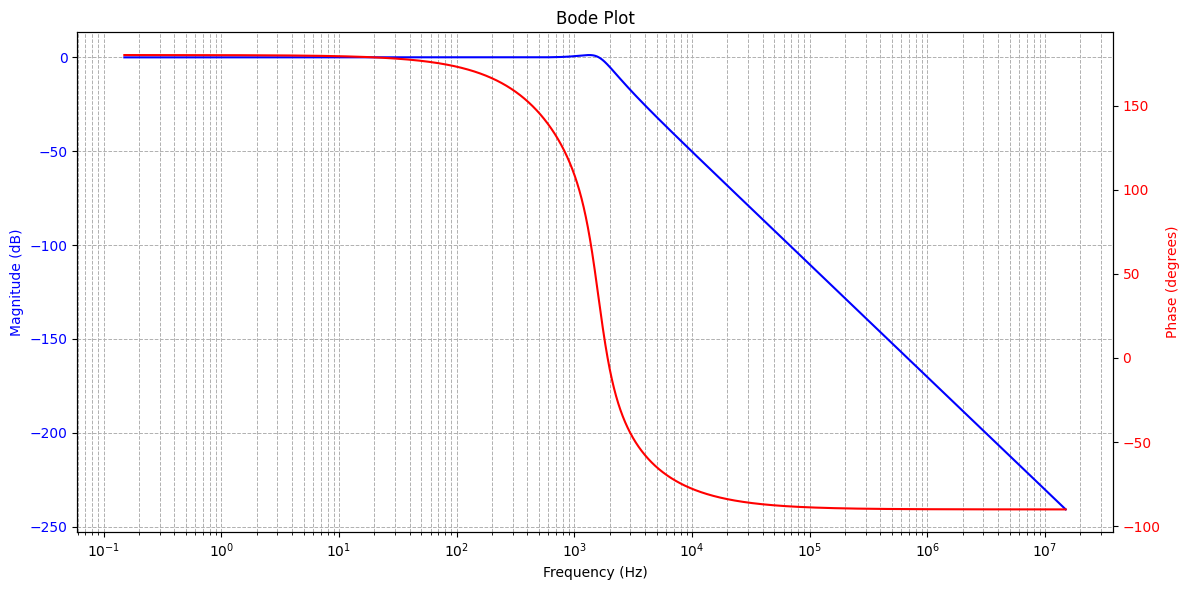


Ganancia en $\omega_{s}$ = (4500.0): -28.866[dB]

Ganancia en $\omega_{c}$ = (1500.0): 0.861[dB]


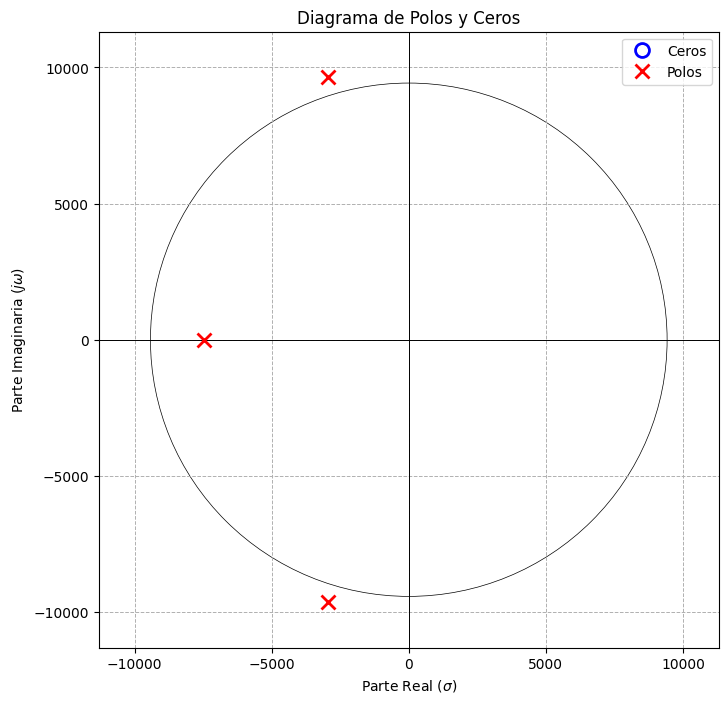

In [9]:
T3_eval = T1_eval * T2_eval
w = sp.sqrt(terms[-1])
(magnitude_db, frequencies, _) = uplt.plot_tf(T3_eval, {}, w_c / (2 * np.pi))

idx = np.argmin(np.abs(frequencies - (3 * w_c) / (2 * np.pi)))
magnitude_at_ws = magnitude_db[idx]
idx = np.argmin(np.abs(frequencies - (1 * w_c) / (2 * np.pi)))
magnitude_at_wc = magnitude_db[idx]

markdown_text = rf"""
Ganancia en $\omega_{{s}}$ = ({(3 * w_c) / (2 * np.pi)}): {magnitude_at_ws:.3f}[dB]

Ganancia en $\omega_{{c}}$ = ({(1 * w_c) / (2 * np.pi)}): {magnitude_at_wc:.3f}[dB]
"""

display(Markdown(markdown_text))

_ = uplt.plot_polos_ceros(T3_eval, w_c, {})

### Simulación con LT Spice - Orden 3

Circuito:

<div align=center>

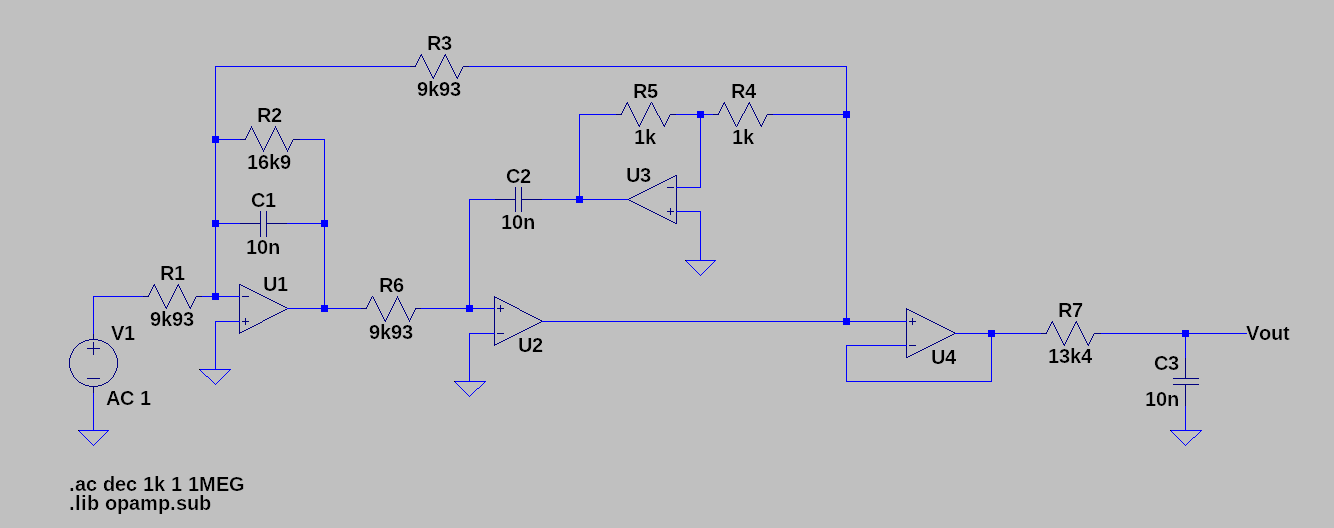

</div>

Módulo y Fase:

<div align=center>

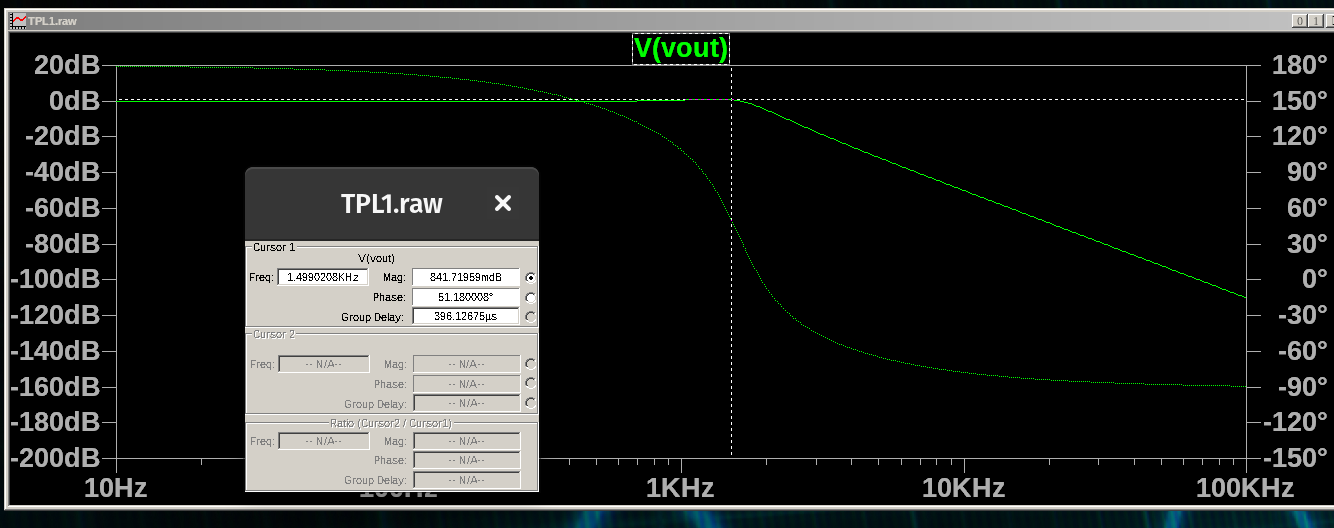

</div>

<a href="./TPL1.asc" download="TPL1.asc">Descargar TPL1.asc</a>

# Análisis en Laboratorio

Se implementa el circuito simulado con el integrado `LM324N`.

- Tensión de alimentación: $\pm 15[V]$
- Tensión de entrada: $\pm 10[Vpp]$

SetUp medición:

<div align=center>

![Setup](./imgs/TPL1_setup.jpeg)

</div>

Se realiza un barrido en frecuencia para obtener el módulo y fase. Se observan los cambios en el osciloscopio y se documenta en una hoja de cálculo:

<div align=center>

![Sweep](./imgs/TPL1_freq_sweep.gif)

</div>

Atenuación, celeste input y amarillo output:

<div align=center>

![Att](./imgs/TPL1_att.jpeg)

</div>

Comportamiento de filtro Cheby, se aprecia una pequeña ganancia en la $\omega_c$, celeste input y amarillo output:

<div align=center>

![Cheby](./imgs/TPL1_cheby.jpeg)

</div>

Con los datos de la tabla se reconstruyen gráficos experimentales del módulo y fase en escala `semilogx`.

In [10]:
df = pd.read_csv("TPL1_meas.csv")

table_html = df.to_html(classes="my-table", border=1, index=False)

# HTML + JS for toggle button and table
html_code = f"""
<button onclick="var tbl = document.getElementById('myTable'); 
                 if(tbl.style.display === 'none') {{
                     tbl.style.display = 'table';
                 }} else {{
                     tbl.style.display = 'none';
                 }}">
  Show/Hide Table
</button>

<div id="myTable" style="display:none;">
  {table_html}
</div>
"""

display(HTML(html_code))

Vin,Vout,Frec,DeltaPhase
10.3,10.300,0.1,4.800
10.3,10.300,0.2,NaN
10.3,10.100,0.3,NaN
10.3,10.100,0.4,NaN
10.1,10.000,0.5,0.840
10.1,10.000,0.6,NaN
10.1,10.000,0.7,NaN
10.1,9.800,0.8,NaN
10.1,9.800,0.9,NaN
10.1,9.600,1.0,0.320


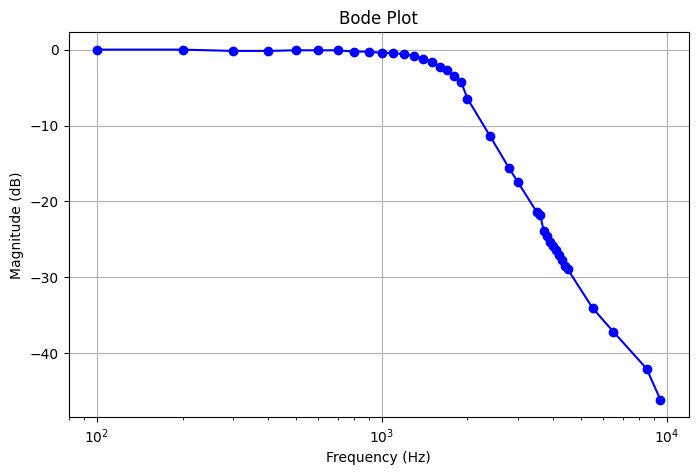

In [11]:
magnitude = 20 * np.log10(df.Vout / df.Vin)
frequencies = df.Frec * 1000

plt.figure(figsize=(8, 5))
plt.semilogx(frequencies, magnitude, marker="o", linestyle="-", color="blue")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Bode Plot")
plt.grid(True)
plt.show()

Para obtener la fase en grados de un filtro, se mide el retraso en tiempo ($\Delta t$) que introduce el filtro en cada frecuencia ($f$). La fase se calcula con la fórmula:

$$
\Delta \varphi = 360^\circ \times f \times \Delta t
$$

donde $\Delta \varphi$ es la fase en grados, $f$ la frecuencia en Hz y $\Delta t$ el retraso en segundos.

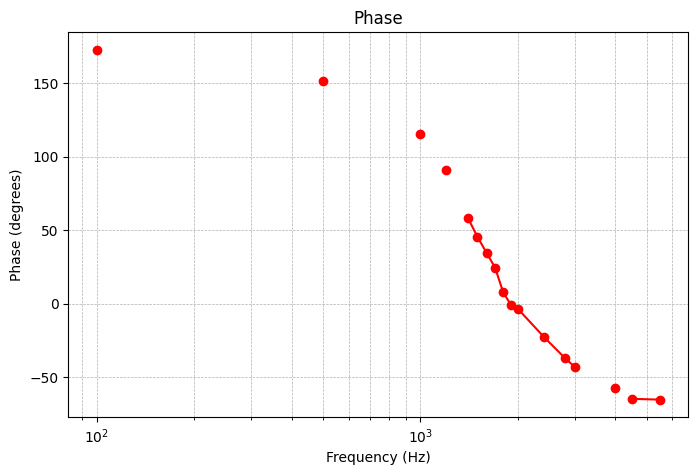

In [12]:
phase = 360 * (frequencies) * (df.DeltaPhase * 1e-3)
plt.figure(figsize=(8, 5))
plt.semilogx(frequencies, phase, marker="o", linestyle="-", color="red")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (degrees)")
plt.title("Phase")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

Como obtuvimos pocos valores a baja frecuencia de forma experimental y además se "saltearon" algunas frecuencias, el módulo `matplotlib.pyplot` no logra interpolar correctamente a baja frecuencia debido a la falta de información.

Para poder visualizar el gráfico e interpretarlo de una mejor manera, se pueden interpolar los puntos. Se procede a utilizar `scipy.interpolate.interp1d`.

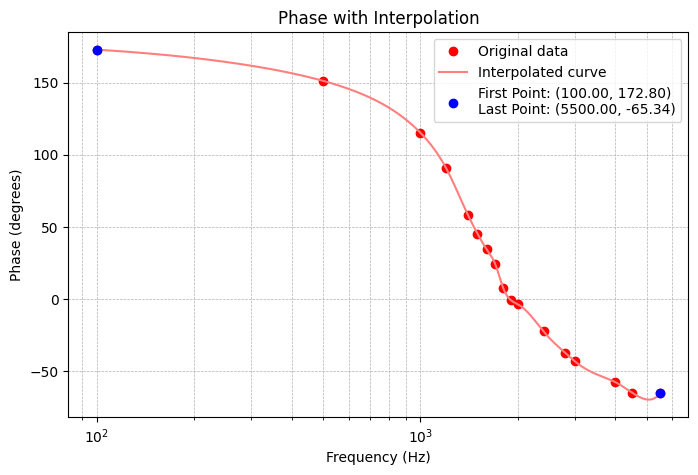

In [13]:
from scipy.interpolate import interp1d

x = frequencies
y = phase

# Remove NaNs or invalid points
mask = ~np.isnan(y)
x = x[mask]
y = y[mask]

interp_func = interp1d(x, y, kind="cubic", fill_value="extrapolate")
x_dense = np.linspace(x.min(), x.max(), 500)
y_dense = interp_func(x_dense)

# Plot original points and interpolated curve
plt.figure(figsize=(8, 5))
plt.semilogx(x, y, "o", label="Original data", color="red")
plt.semilogx(x_dense, y_dense, "-", color="#FF7F7F", label="Interpolated curve")
plt.scatter(
    [x_dense[0], x_dense[-1]],
    [y_dense[0], y_dense[-1]],
    color="blue",
    label=f"First Point: ({x_dense[0]:.2f}, {y_dense[0]:.2f})\nLast Point: ({x_dense[-1]:.2f}, {y_dense[-1]:.2f})",
    zorder=5,
)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (degrees)")
plt.title("Phase with Interpolation")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

Además de los datos obtenidos manualmente, se utilizó un analizador de audio para obtener de manera más rápida y práctica los gráficos de módulo y fase. A continuación, se señalan algunos aspectos importantes del gráfico generado en las siguientes celdas.

Primero, la resta entre canales para obtener la fase se hizo en el orden inverso; por lo tanto, es necesario cambiar el signo del array de datos para corregirlo.

Segundo, se observan saltos bruscos en la gráfica, lo cual se debe a la incertidumbre e imprecisión propias de la medición de señales muy atenuadas. Los datos obtenidos manualmente cubren hasta 10 kHz, mientras que el analizador de audio mide hasta 20 kHz. Para mitigar este efecto, se procede a invertir el signo de los saltos bruscos detectados en el array.

In [14]:
df = pd.read_csv("TPL1_automatic_meas.csv")
df.drop("ch1", axis=1, inplace=True)

table_html = df.to_html(classes="my-table", border=1, index=False)

# HTML + JS for toggle button and table
html_code = f"""
<button onclick="var tbl = document.getElementById('myTable'); 
                 if(tbl.style.display === 'none') {{
                     tbl.style.display = 'table';
                 }} else {{
                     tbl.style.display = 'none';
                 }}">
  Show/Hide Table
</button>

<div id="myTable2" style="display:none;">
  {table_html}
</div>
"""

display(HTML(html_code))

f,ch2
20.000000,50.347328
25.379220,-177.745682
32.205241,-177.410385
40.867194,-176.894440
51.858876,-176.184235
65.806891,-175.267532
83.506379,-174.089249
105.966338,-172.594894
134.467151,-170.687531
170.633570,-168.254944


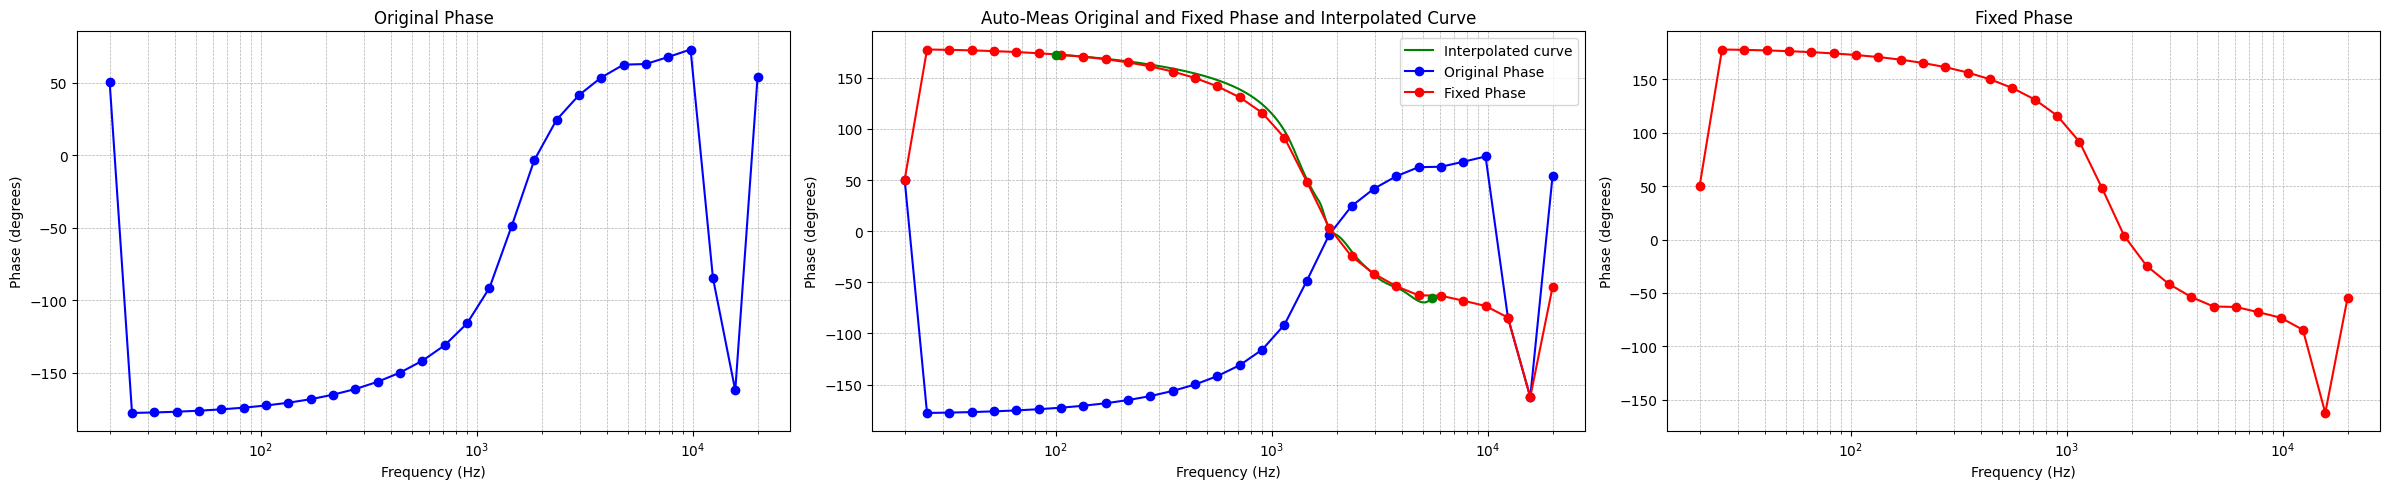

In [15]:
frequencies = df.f
phase = df.ch2
phase_fixed = -df.ch2

phase_fixed = [
    -p if freq > 10000 and p > 0 else p for freq, p in zip(frequencies, phase_fixed)
]
phase_fixed[0] = -phase_fixed[0]

fig, axs = plt.subplots(1, 3, figsize=(24, 5))

# Left plot: original phase
axs[0].semilogx(frequencies, phase, marker="o", linestyle="-", color="blue")
axs[0].set_xlabel("Frequency (Hz)")
axs[0].set_ylabel("Phase (degrees)")
axs[0].set_title("Original Phase")
axs[0].grid(True, which="both", linestyle="--", linewidth=0.5)

# Middle plot: both original and fixed phase
axs[1].scatter(
    [x_dense[0], x_dense[-1]],
    [y_dense[0], y_dense[-1]],
    color="green",
    zorder=5,
)
axs[1].semilogx(x_dense, y_dense, "-", color="green", label="Interpolated curve")
axs[1].semilogx(
    frequencies, phase, marker="o", linestyle="-", label="Original Phase", color="blue"
)
axs[1].semilogx(
    frequencies,
    phase_fixed,
    marker="o",
    linestyle="-",
    label="Fixed Phase",
    color="red",
)
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("Phase (degrees)")
axs[1].set_title("Auto-Meas Original and Fixed Phase and Interpolated Curve")
axs[1].legend()
axs[1].grid(True, which="both", linestyle="--", linewidth=0.5)

# Right plot: fixed phase
axs[2].semilogx(frequencies, phase_fixed, marker="o", linestyle="-", color="red")
axs[2].set_xlabel("Frequency (Hz)")
axs[2].set_ylabel("Phase (degrees)")
axs[2].set_title("Fixed Phase")
axs[2].grid(True, which="both", linestyle="--", linewidth=0.5)

plt.tight_layout()
plt.show()

Se grafica en azul la fase obtenida a partir de los datos crudos, en rojo la fase ajustada según las consideraciones previas, y en verde se superpone la fase con los datos obtenidos manualmente mediante el osciloscopio.

A continuación se agregan las imagenes que produce el analizador de audio de manera automática. Se aprecia que la Fase es la misma y el módulo concuerda con el gráfico a partir de los datos manuales.

![Grupo_1_LPF_Fase.jpeg](./imgs/Grupo_1_LPF_Fase.jpeg) ![Grupo_1_LPF_Modulo.jpeg](./imgs/Grupo_1_LPF_Modulo.jpeg)

# Conclusiones y Comentarios Finales

Tras diseñar y simular con éxito el filtro a partir de una plantilla, se llevó a la práctica el circuito utilizando un LM324N, un integrado que contiene cuatro amplificadores operacionales similares al LM741.

Para verificar el correcto funcionamiento del filtro, se empleó un generador de señales de frecuencia variable junto con un osciloscopio, permitiendo realizar un barrido en frecuencia. De esta forma, se obtuvieron tanto la fase como la magnitud de la señal, datos que fueron transferidos a un notebook para elaborar los gráficos correspondientes.

Finalmente, se utilizó un analizador de audio que realiza el barrido en frecuencia de forma automática, proporcionando directamente los gráficos y un conjunto de datos en formato .csv.

Las mediciones obtenidas mediante el osciloscopio y el analizador de audio concuerdan con los resultados de las simulaciones realizadas previamente, lo que confirma la validez del diseño y el correcto desempeño del filtro en la práctica.